# Particle-spray Stream Modeling with streamspraydf

The particle-spray technique generates tidal streams by "spraying" particles
from the Lagrange points of a progenitor cluster as it orbits in a gravitational
potential. Each particle is given a small velocity kick and then integrated forward
in the potential. galpy provides two implementations:

- `chen24spraydf`: the spray model from Chen et al. (2024)
- `fardal15spraydf`: the spray model from Fardal et al. (2015)

These are faster to set up than `streamdf` and work in any potential.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.df import chen24spraydf, fardal15spraydf
from galpy.potential import LogarithmicHaloPotential
from galpy.orbit import Orbit

## Setup

We set up a potential and a progenitor orbit. The particle-spray classes
only need the potential and the progenitor orbit (no action-angle machinery).

In [2]:
lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
prog = Orbit([1.56148083, 0.35081535, -1.97302, 0.33446162, -0.16101384, -0.7166])

## Initialize chen24spraydf

We create a spray model for the leading tail. The key parameters are:

- `progenitor_mass`: mass of the progenitor in solar masses
- `progenitor`: the progenitor orbit
- `pot`: the gravitational potential
- `tdisrupt`: time since disruption began (in Gyr when using physical units)
- `tail`: which tail to model (`'leading'`, `'trailing'`, or `'both'`)

In [3]:
spdf_lead = chen24spraydf(
    progenitor_mass=10**4.0,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5,
    tail="leading",
)

## Sample stream particles

The `sample` method generates stream particles by spraying `n` particles
from the progenitor's Lagrange points and integrating them forward.

In [4]:
lead_stream = spdf_lead.sample(n=500)

Let's visualize the sampled stream particles:

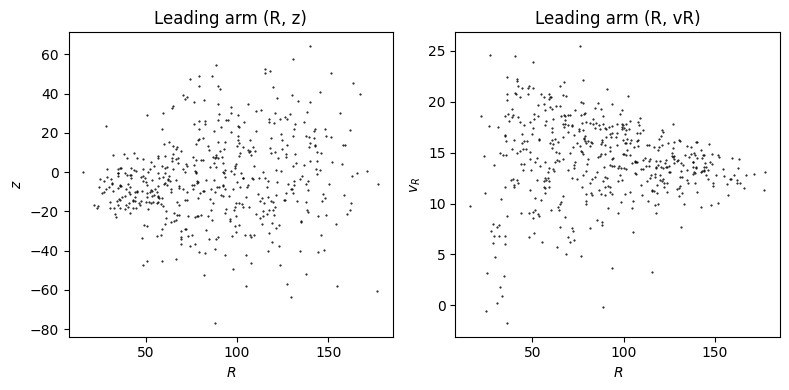

In [5]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(lead_stream.R(), lead_stream.z(), "k.", ms=1)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Leading arm (R, z)")
plt.subplot(1, 2, 2)
plt.plot(lead_stream.R(), lead_stream.vR(), "k.", ms=1)
plt.xlabel(r"$R$")
plt.ylabel(r"$v_R$")
plt.title("Leading arm (R, vR)")
plt.tight_layout()

## Leading and trailing arms with tail='both'

Using `tail='both'` generates both arms in one call. This is more
efficient than creating separate leading and trailing instances.

In [6]:
spdf_both = chen24spraydf(
    progenitor_mass=10**4.0,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5,
    tail="both",
)
both_stream = spdf_both.sample(n=1000)

Plotting both arms in Cartesian coordinates:

(np.float64(-139.7387239905264),
 np.float64(164.03353642628662),
 np.float64(-207.47474767848954),
 np.float64(186.0954987876926))

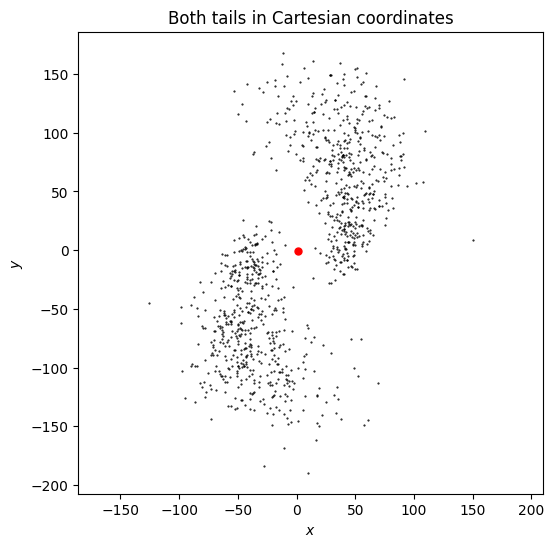

In [7]:
plt.figure(figsize=(6, 6))
plt.plot(both_stream.x(), both_stream.y(), "k.", ms=1)
plt.plot(prog.x(), prog.y(), "ro", ms=5)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Both tails in Cartesian coordinates")
plt.axis("equal")

## Using fardal15spraydf

`fardal15spraydf` provides an alternative spray model based on
Fardal et al. (2015). The interface is the same.

In [8]:
spdf_fardal = fardal15spraydf(
    progenitor_mass=10**4.0,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5,
    tail="both",
)
fardal_stream = spdf_fardal.sample(n=1000)

Comparing the two spray models side by side:

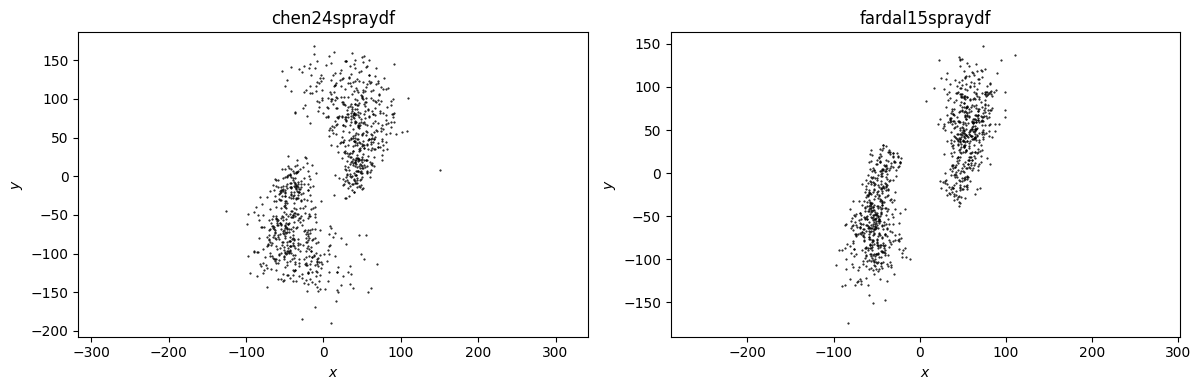

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(both_stream.x(), both_stream.y(), "k.", ms=1)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("chen24spraydf")
plt.axis("equal")
plt.subplot(1, 2, 2)
plt.plot(fardal_stream.x(), fardal_stream.y(), "k.", ms=1)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("fardal15spraydf")
plt.axis("equal")
plt.tight_layout()

## Progenitor self-gravity with progpot

The `chen24spraydf` model can include the progenitor's self-gravity using the
`progpot` parameter. This is a potential representing the progenitor cluster
(e.g., a `PlummerPotential`), which is used when computing the tidal radius
and the velocity distribution of stripped stars:

Text(0.5, 1.0, 'chen24spraydf with progenitor self-gravity')

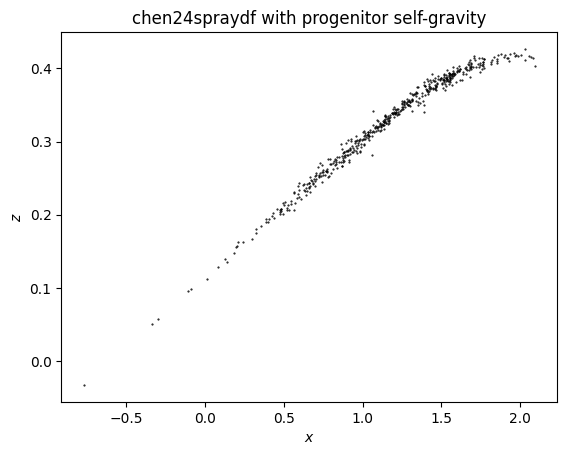

In [10]:
from astropy import units
from galpy.potential import PlummerPotential

progpot = PlummerPotential(2 * 10.0**4.0 * units.Msun, 4.0 * units.pc)
spdf_with_prog = chen24spraydf(
    progenitor_mass=2 * 10.0**4.0 * units.Msun,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5 * units.Gyr,
    tail="both",
    progpot=progpot,
)
stream_with_prog = spdf_with_prog.sample(n=500)
plt.plot(stream_with_prog.x(), stream_with_prog.z(), "k.", ms=1)
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.title("chen24spraydf with progenitor self-gravity")

## Using physical units

The spray DFs can also be initialized with physical units for the progenitor mass,
disruption time, etc. using astropy Quantities, as shown above with
`tdisrupt=4.5*units.Gyr` and `progenitor_mass=2*10.**4.*units.Msun`.

## Integrating sampled orbits

The `sample` method can return integrated orbits (to the present time) using
`integrate=True`. You can also get the stripping times with `returndt=True`.
The returned `Orbit` object can be further integrated or analyzed:

Text(0.5, 1.0, 'Integrated stream particles with progenitor orbit')

Locator attempting to generate 7726 ticks ([-83.37999999999998, ..., 71.11999999999999]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 7726 ticks ([-83.37999999999998, ..., 71.11999999999999]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 7726 ticks ([-83.37999999999998, ..., 71.11999999999999]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 1224 ticks ([-130.6, ..., 114.00000000000003]), which exceeds Locator.MAXTICKS (1000).


...

Locator attempting to generate 1224 ticks ([-130.6, ..., 114.00000000000003]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 1224 ticks ([-130.6, ..., 114.00000000000003]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 7726 ticks ([-83.37999999999998, ..., 71.11999999999999]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 7726 ticks ([-83.37999999999998, ..., 71.11999999999999]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 7726 ticks ([-83.37999999999998, ..., 71.11999999999999]), which exceeds Locator.MAXTICKS (1000).


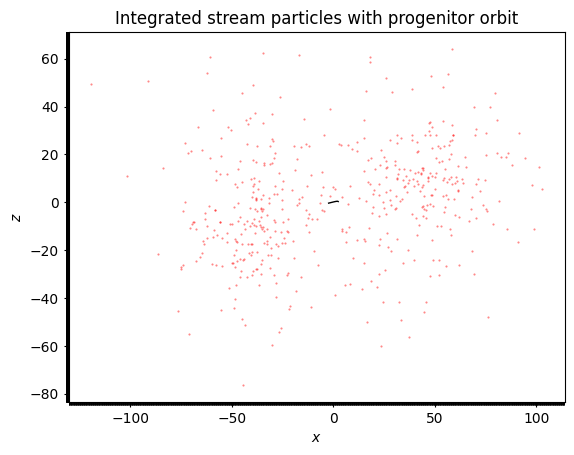

In [11]:
# Sample with integration and stripping times
orbs_integrated, dt = spdf_both.sample(n=500, returndt=True, integrate=True)

# Integrate the progenitor for context
ts_prog = numpy.linspace(0.0, 3.0, 301)
prog.integrate(ts_prog, lp)
prog.integrate(-ts_prog, lp)

# Plot the integrated stream with progenitor orbit
prog.plot(d1="x", d2="z", color="k", lw=1)
plt.plot(orbs_integrated.x(), orbs_integrated.z(), "r.", ms=1, alpha=0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.title("Integrated stream particles with progenitor orbit")